# Data Understanding & Exploratory Data Analysis (EDA)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy import stats

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
import warnings
warnings.filterwarnings('ignore')

## 1. Load Data\nRead all four CSV files using Pandas.

In [2]:
raw_data_dir = '../data/raw/'

# Load Plant 1
p1_gen = pd.read_csv(raw_data_dir + 'Plant_1_Generation_Data.csv')
p1_wea = pd.read_csv(raw_data_dir + 'Plant_1_Weather_Sensor_Data.csv')

# Load Plant 2
p2_gen = pd.read_csv(raw_data_dir + 'Plant_2_Generation_Data.csv')
p2_wea = pd.read_csv(raw_data_dir + 'Plant_2_Weather_Sensor_Data.csv')

print("Plant 1 Generation shape:", p1_gen.shape)
print("Plant 1 Weather shape:", p1_wea.shape)
print("Plant 2 Generation shape:", p2_gen.shape)
print("Plant 2 Weather shape:", p2_wea.shape)

Plant 1 Generation shape: (68778, 7)
Plant 1 Weather shape: (3182, 6)
Plant 2 Generation shape: (67698, 7)
Plant 2 Weather shape: (3259, 6)


### Parse DATE_TIME carefully\nParse `DATE_TIME` column since Plant 1 uses format `dd-mm-yyyy hh:mm` while others might use `yyyy-mm-dd hh:mm:ss`.

In [3]:
def parse_datetime(df):
    df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'], errors='coerce', dayfirst=True)
    return df

p1_gen = parse_datetime(p1_gen)
p1_wea = parse_datetime(p1_wea)
p2_gen = parse_datetime(p2_gen)
p2_wea = parse_datetime(p2_wea)

# Add PLANT_ID and PLANT_NAME
p1_gen['PLANT_ID'] = 4135001
p1_wea['PLANT_ID'] = 4135001
p2_gen['PLANT_ID'] = 4136001
p2_wea['PLANT_ID'] = 4136001

p1_gen['PLANT_NAME'] = 'Plant 1'
p1_wea['PLANT_NAME'] = 'Plant 1'
p2_gen['PLANT_NAME'] = 'Plant 2'
p2_wea['PLANT_NAME'] = 'Plant 2'

# Combine Generation Data
df_gen = pd.concat([p1_gen, p2_gen], ignore_index=True)

# Combine Weather Data
df_wea = pd.concat([p1_wea, p2_wea], ignore_index=True)

# Create common time columns
for df in [df_gen, df_wea]:
    df['DATE'] = df['DATE_TIME'].dt.date
    df['TIME'] = df['DATE_TIME'].dt.time
    df['HOUR'] = df['DATE_TIME'].dt.hour
    df['MINUTE'] = df['DATE_TIME'].dt.minute

## 2. Data Quality Checks

In [4]:
# 2.1 Dataset shape summary
shapes = {
    'Dataset': ['Plant 1 Gen', 'Plant 1 Weather', 'Plant 2 Gen', 'Plant 2 Weather', 'Combined Gen', 'Combined Weather'],
    'Rows': [p1_gen.shape[0], p1_wea.shape[0], p2_gen.shape[0], p2_wea.shape[0], df_gen.shape[0], df_wea.shape[0]],
    'Cols': [p1_gen.shape[1], p1_wea.shape[1], p2_gen.shape[1], p2_wea.shape[1], df_gen.shape[1], df_wea.shape[1]]
}
df_shapes = pd.DataFrame(shapes)
display(df_shapes)

,Dataset,Rows,Cols
0,Plant 1 Gen,68778,8
1,Plant 1 Weather,3182,7
2,Plant 2 Gen,67698,8
3,Plant 2 Weather,3259,7
4,Combined Gen,136476,12
5,Combined Weather,6441,11


In [5]:
# 2.2 Missing value check
missing_gen = df_gen.isnull().sum()
missing_wea = df_wea.isnull().sum()
print("Missing values in Generation Data:\n", missing_gen[missing_gen > 0])
print("\nMissing values in Weather Data:\n", missing_wea[missing_wea > 0])

Missing values in Generation Data:
 Series([], dtype: int64)

Missing values in Weather Data:
 Series([], dtype: int64)


In [6]:
# 2.3 Duplicate row count
dup_gen = df_gen.duplicated().sum()
dup_wea = df_wea.duplicated().sum()
print(f"Duplicate rows in Generation Data: {dup_gen}")
print(f"Duplicate rows in Weather Data: {dup_wea}")

Duplicate rows in Generation Data: 0
Duplicate rows in Weather Data: 0


In [7]:
# 2.4 Date range check
print("Generation Data Date Range:")
print("Min:", df_gen['DATE_TIME'].min())
print("Max:", df_gen['DATE_TIME'].max())

print("\nWeather Data Date Range:")
print("Min:", df_wea['DATE_TIME'].min())
print("Max:", df_wea['DATE_TIME'].max())

Generation Data Date Range:
Min: 2020-05-15 00:00:00
Max: 2020-06-17 23:45:00

Weather Data Date Range:
Min: 2020-05-15 00:00:00
Max: 2020-06-17 23:45:00


In [8]:
# 2.5 Number of inverters per plant
inverters_per_plant = df_gen.groupby('PLANT_NAME')['SOURCE_KEY'].nunique()
print("Number of inverters per plant:")
print(inverters_per_plant)

Number of inverters per plant:
PLANT_NAME
Plant 1    22
Plant 2    22
Name: SOURCE_KEY, dtype: int64


### 2.6 Descriptive Statistics\nBasic statistics for key numerical variables to understand distributions, min/max values, and potential outliers.

In [9]:
# 2.6 Descriptive statistics for Generation Data
print("=" * 80)
print("Generation Data - Key Variables Statistics:")
print("=" * 80)
display(df_gen[['DC_POWER', 'AC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD']].describe())

print("\n" + "=" * 80)
print("Weather Data - Key Variables Statistics:")
print("=" * 80)
display(df_wea[['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']].describe())

Generation Data - Key Variables Statistics:


,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
count,136476.000000,136476.000000,136476.000000,1.364760e+05
mean,1708.541497,274.803511,3295.433783,3.303821e+08
std,3222.181273,380.182569,3035.294425,6.085705e+08
min,0.000000,0.000000,0.000000,0.000000e+00
25%,0.000000,0.000000,28.321429,6.520020e+06
50%,6.050000,3.506905,2834.803572,7.269333e+06
75%,1155.788333,532.673333,5992.000000,2.826096e+08
max,14471.125000,1410.950000,9873.000000,2.247916e+09



Weather Data - Key Variables Statistics:


,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,6441.000000,6441.000000,6441.000000
mean,26.815672,31.941762,0.230551
std,3.938901,11.835033,0.306877
min,20.398505,18.140415,0.000000
25%,23.662696,22.429024,0.000000
50%,25.954460,26.394380,0.022282
75%,29.355584,40.821388,0.443340
max,39.181638,66.635953,1.221652


## 3. Data Correction: Plant 1 DC_POWER decimal error\nCorrect Plant 1 DC_POWER scaling error as instructed.\n\n**Objective Review**: Dividing `DC_POWER` by 10 brings the efficiency back to a normal level (~97.8%). However, it is important to verify with the engineering team whether the root cause is a sensor configuration error or an actual hardware issue. Documenting the reason clearly is crucial for data integrity. From a data engineering perspective, this is a significant risk (Data Assumption Risk). If deployed in production and the hardware/software bug is silently fixed on the device side, this divide-by-10 code would corrupt all new data. The root cause must be clarified.\n\n**Note on Efficiency Calculation (Efficiency = AC / DC)**: At dawn/dusk times (low Irradiation, DC_POWER ≈ 0), this calculation easily produces nonsensical values or noise. Efficiency should not be calculated for periods when irradiation is below a minimum threshold.

In [10]:
# 3. DC/AC efficiency check before and after Plant 1 correction

# Raw Efficiency
df_gen['DC_POWER_RAW'] = df_gen['DC_POWER']
df_gen['EFFICIENCY_RAW'] = np.where(df_gen['DC_POWER_RAW'] > 0, df_gen['AC_POWER'] / df_gen['DC_POWER_RAW'], 0)

print("Median Raw Efficiency:")
print(df_gen[df_gen['DC_POWER_RAW'] > 0].groupby('PLANT_NAME')['EFFICIENCY_RAW'].median())

# Correction: Plant 1 DC_POWER is 10x too high
df_gen['DC_POWER_CORRECTED'] = np.where(df_gen['PLANT_ID'] == 4135001, df_gen['DC_POWER_RAW'] / 10, df_gen['DC_POWER_RAW'])
df_gen['EFFICIENCY_CORRECTED'] = np.where(df_gen['DC_POWER_CORRECTED'] > 0, df_gen['AC_POWER'] / df_gen['DC_POWER_CORRECTED'], 0)

print("\nMedian Corrected Efficiency:")
print(df_gen[df_gen['DC_POWER_CORRECTED'] > 0].groupby('PLANT_NAME')['EFFICIENCY_CORRECTED'].median())

Median Raw Efficiency:
PLANT_NAME
Plant 1    0.097845
Plant 2    0.978432
Name: EFFICIENCY_RAW, dtype: float64

Median Corrected Efficiency:
PLANT_NAME
Plant 1    0.978451
Plant 2    0.978432
Name: EFFICIENCY_CORRECTED, dtype: float64


## 4. Merge Generation and Weather Data\nMerge by `PLANT_ID` and `DATE_TIME`.\n\n**Unit Assumptions:**\n- `AC_POWER` and `DC_POWER` are in **kW** (kilowatts)\n- Each data interval is **15 minutes** (0.25 hours), so `ENERGY_KWH = AC_POWER * 0.25`\n- CO2 emission factor: **0.703 kg CO2/kWh** — this is the India national grid average emission factor (Source: CEA CO2 Baseline Database, 2018-2019). This value varies by country and grid region.

In [11]:
# [FIX #1] Rename weather SOURCE_KEY to avoid column conflict during merge
# The original code had: df_wea.rename(columns={'SOURCE_KEY': 'SOURCE_KEY'}) — which did nothing!
df_wea = df_wea.rename(columns={'SOURCE_KEY': 'WEATHER_SENSOR_KEY'})

# Record row count before merge for comparison
gen_rows_before = len(df_gen)

df_merged = pd.merge(df_gen, df_wea[['DATE_TIME', 'PLANT_ID', 'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION']],
                     on=['DATE_TIME', 'PLANT_ID'],
                     how='inner')

# [FIX #2] Check how many rows were lost during inner join and explain
gen_rows_after = len(df_merged)
rows_lost = gen_rows_before - gen_rows_after
print(f"Generation rows before merge: {gen_rows_before}")
print(f"Merged rows after inner join: {gen_rows_after}")
print(f"Rows lost during merge: {rows_lost}")
if rows_lost > 0:
    # Find which DATE_TIME + PLANT_ID combinations exist in gen but not in weather
    gen_keys = set(zip(df_gen['DATE_TIME'], df_gen['PLANT_ID']))
    wea_keys = set(zip(df_wea['DATE_TIME'], df_wea['PLANT_ID']))
    missing_keys = gen_keys - wea_keys
    print(f"\nMissing weather data for {len(missing_keys)} time-plant combinations:")
    for dt, pid in sorted(missing_keys):
        plant_name = 'Plant 1' if pid == 4135001 else 'Plant 2'
        print(f"  - {dt} | {plant_name}")

# [FIX #6] Calculate ENERGY_KWH_INTERVAL with clear unit documentation
# Giả định AC_POWER có đơn vị là kW, do đó ENERGY_KWH_INTERVAL = AC_POWER * 0.25 (15 phút = 0.25 giờ)
# Energy (kWh) = Power (kW) x Time (hours)
df_merged['ENERGY_KWH_INTERVAL'] = df_merged['AC_POWER'] * 0.25

# CO2 avoided: using India grid emission factor (CEA 2018-2019)
# Source: Central Electricity Authority of India, CO2 Baseline Database
CO2_EMISSION_FACTOR = 0.703  # kg CO2 per kWh
df_merged['CO2_AVOIDED_KG'] = df_merged['ENERGY_KWH_INTERVAL'] * CO2_EMISSION_FACTOR

# [FIX #5] Peer comparison using leave-one-out average (VECTORIZED with transform)
# PERFORMANCE FIX: Replaced slow groupby().apply() with vectorized transform()
# The old approach used a Python function called for each group — very slow on 130k+ rows.
# transform() computes group statistics in a single vectorized pass — much faster.
group_sum = df_merged.groupby(['PLANT_ID', 'DATE_TIME'])['AC_POWER'].transform('sum')
group_count = df_merged.groupby(['PLANT_ID', 'DATE_TIME'])['AC_POWER'].transform('count')

# Leave-one-out: exclude the current inverter's own value from the peer average to avoid self-bias
df_merged['PEER_AVG_AC_POWER'] = np.where(
    group_count > 1,
    (group_sum - df_merged['AC_POWER']) / (group_count - 1),
    0.0
)
df_merged['POWER_GAP_FROM_PEER'] = df_merged['PEER_AVG_AC_POWER'] - df_merged['AC_POWER']
df_merged['POWER_GAP_PERCENT'] = np.where(
    df_merged['PEER_AVG_AC_POWER'] > 0,
    df_merged['POWER_GAP_FROM_PEER'] / df_merged['PEER_AVG_AC_POWER'],
    0
)

print(f"\nMerged data shape: {df_merged.shape}")

Generation rows before merge: 136476
Merged rows after inner join: 136472
Rows lost during merge: 4

Missing weather data for 1 time-plant combinations:
  - 2020-06-03 14:00:00 | Plant 1

Merged data shape: (136472, 24)


## 5. Exploratory Visualizations

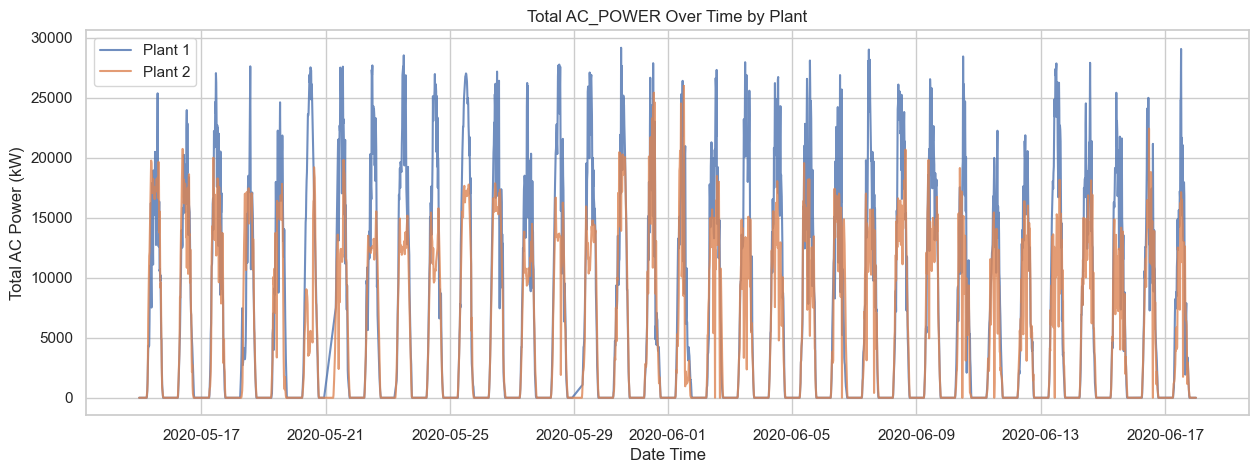

In [12]:
# 5.1 Line chart: total AC_POWER over time by plant
plant1_power = df_merged[df_merged['PLANT_NAME'] == 'Plant 1'].groupby('DATE_TIME')['AC_POWER'].sum()
plant2_power = df_merged[df_merged['PLANT_NAME'] == 'Plant 2'].groupby('DATE_TIME')['AC_POWER'].sum()

plt.figure(figsize=(15, 5))
plt.plot(plant1_power.index, plant1_power.values, label='Plant 1', alpha=0.8)
plt.plot(plant2_power.index, plant2_power.values, label='Plant 2', alpha=0.8)
plt.title('Total AC_POWER Over Time by Plant')
plt.xlabel('Date Time')
plt.ylabel('Total AC Power (kW)')
plt.legend()
plt.show()

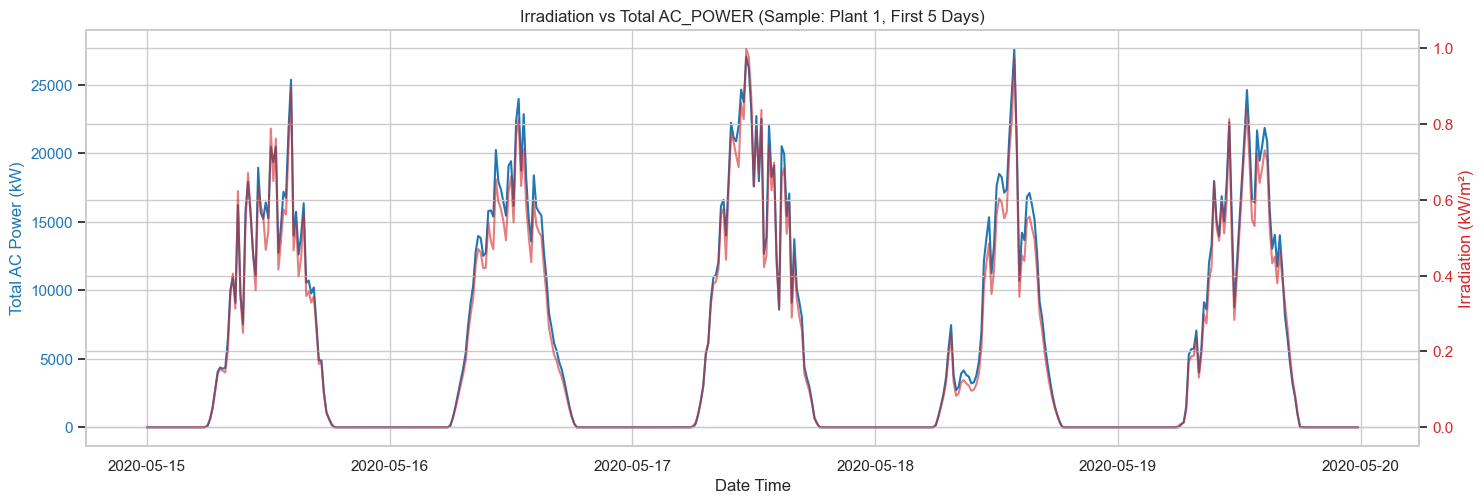

In [13]:
# 5.2 Line chart: irradiation vs total AC_POWER (sample: Plant 1, first 5 days)
fig, ax1 = plt.subplots(figsize=(15, 5))

mask = (df_merged['PLANT_NAME'] == 'Plant 1') & (df_merged['DATE_TIME'] < '2020-05-20')
sample_data = df_merged[mask].groupby('DATE_TIME').agg({'AC_POWER': 'sum', 'IRRADIATION': 'mean'}).reset_index()

color = 'tab:blue'
ax1.set_xlabel('Date Time')
ax1.set_ylabel('Total AC Power (kW)', color=color)
ax1.plot(sample_data['DATE_TIME'], sample_data['AC_POWER'], color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Irradiation (kW/m²)', color=color)
ax2.plot(sample_data['DATE_TIME'], sample_data['IRRADIATION'], color=color, alpha=0.6)
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()
plt.title('Irradiation vs Total AC_POWER (Sample: Plant 1, First 5 Days)')
plt.show()

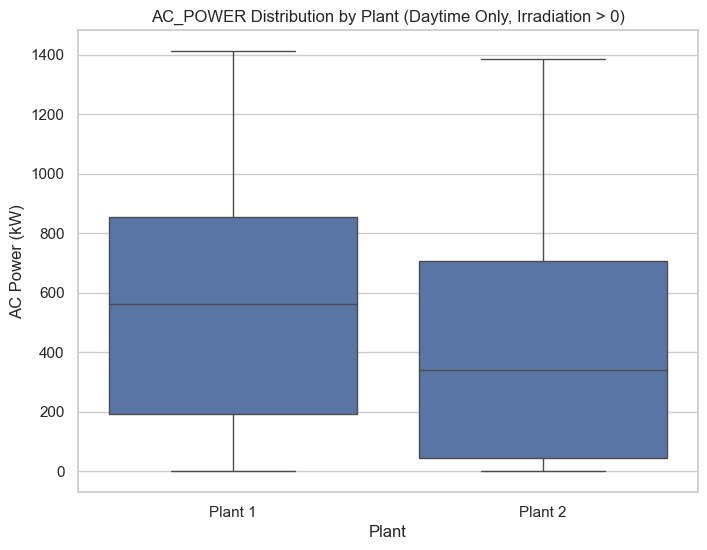

In [14]:
# 5.3 Boxplot: AC_POWER by plant — DAYTIME ONLY (IRRADIATION > 0)
# FIX: Including nighttime records (AC_POWER = 0) would heavily skew the distribution
# and mask the actual daytime generation pattern. We filter to irradiation > 0.
plt.figure(figsize=(8, 6))
sns.boxplot(x='PLANT_NAME', y='AC_POWER', data=df_merged[df_merged['IRRADIATION'] > 0])
plt.title('AC_POWER Distribution by Plant (Daytime Only, Irradiation > 0)')
plt.xlabel('Plant')
plt.ylabel('AC Power (kW)')
plt.show()

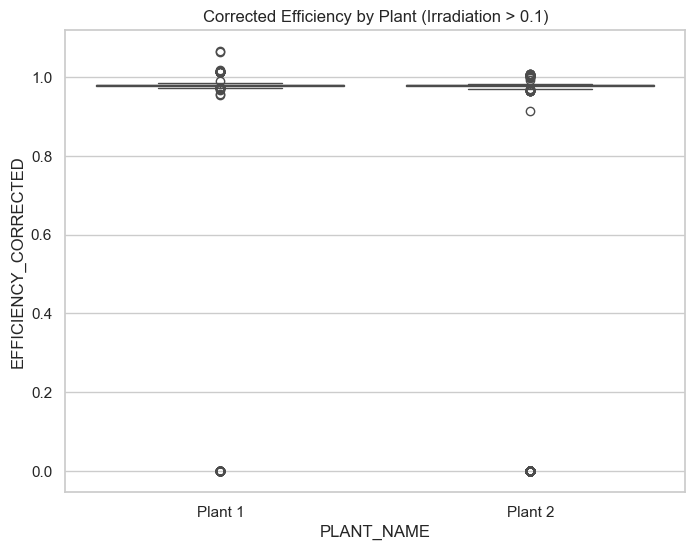

In [15]:
# 5.4 Boxplot: corrected efficiency by plant (only generating hours)
plt.figure(figsize=(8, 6))
sns.boxplot(x='PLANT_NAME', y='EFFICIENCY_CORRECTED', data=df_merged[df_merged['IRRADIATION'] > 0.1])
plt.title('Corrected Efficiency by Plant (Irradiation > 0.1)')
plt.show()

### 5.5 Boxplots for Key Variables (Outlier Detection)\nVisual inspection of distributions to identify potential outliers in key numerical variables.

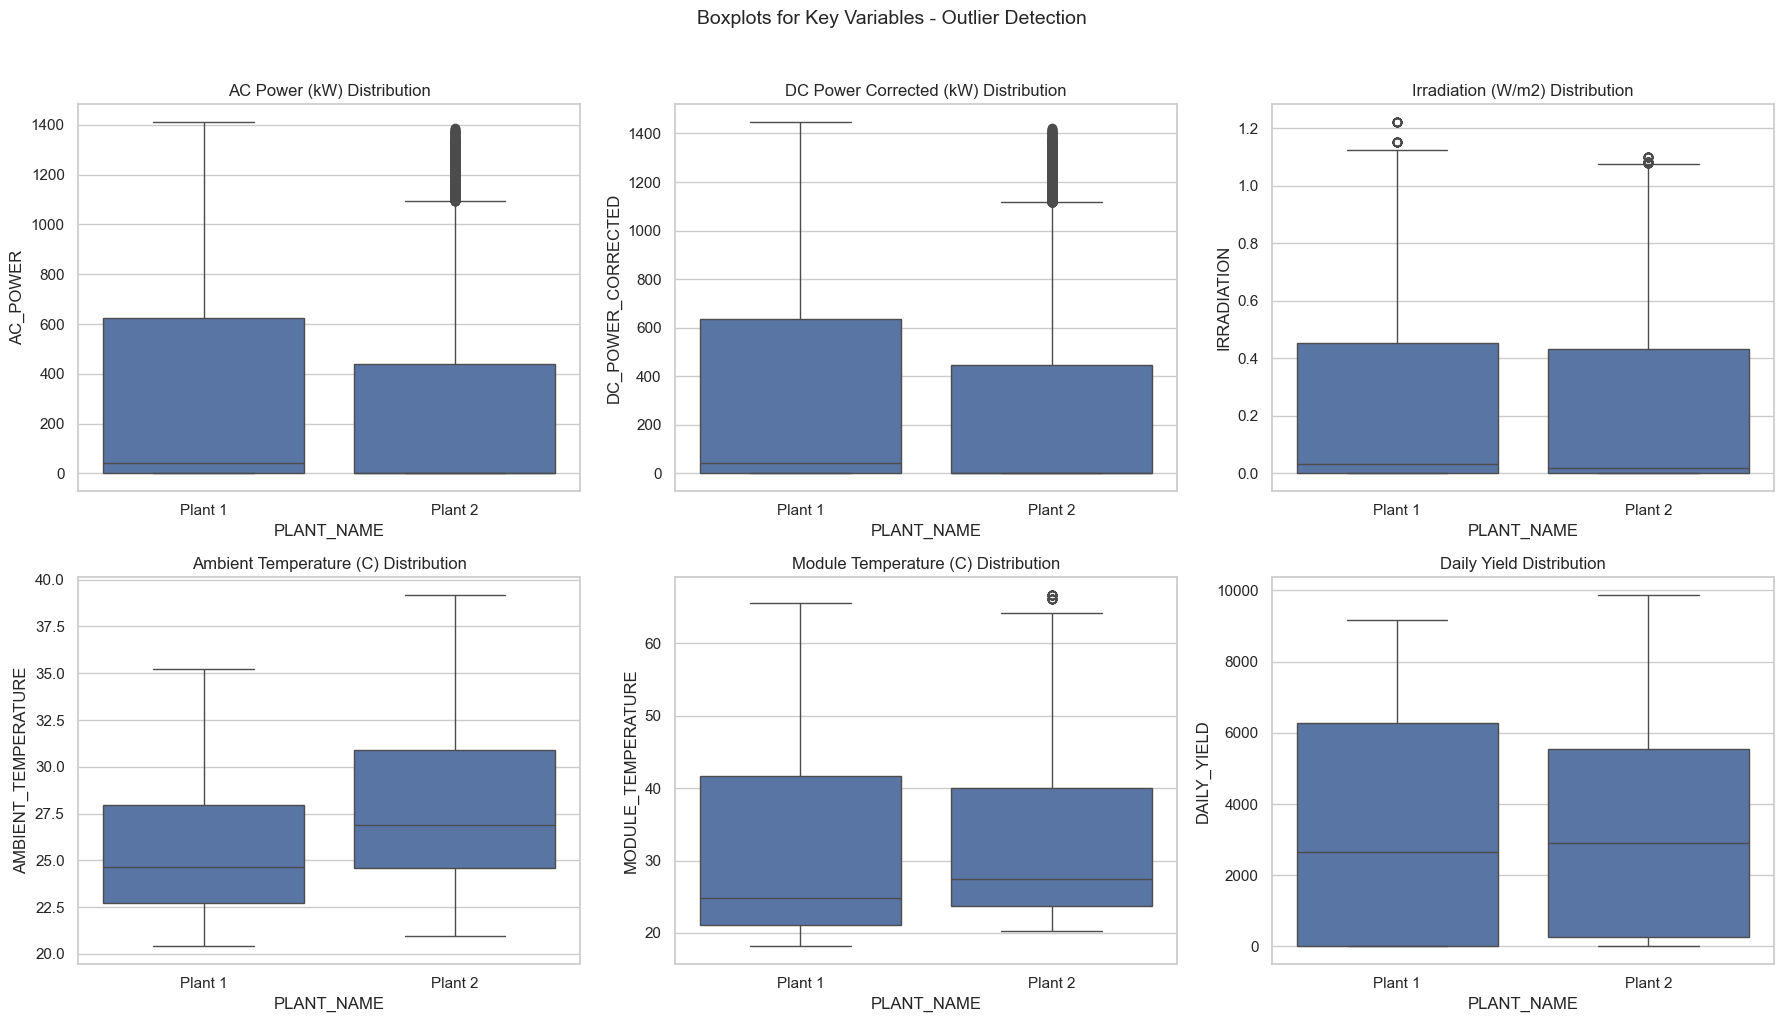

In [16]:
# 5.5 Boxplots for key numerical variables - outlier detection
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

variables = ['AC_POWER', 'DC_POWER_CORRECTED', 'IRRADIATION',
             'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'DAILY_YIELD']
titles = ['AC Power (kW)', 'DC Power Corrected (kW)', 'Irradiation (W/m2)',
          'Ambient Temperature (C)', 'Module Temperature (C)', 'Daily Yield']

for idx, (var, title) in enumerate(zip(variables, titles)):
    row, col = idx // 3, idx % 3
    if var in df_merged.columns:
        sns.boxplot(x='PLANT_NAME', y=var, data=df_merged, ax=axes[row, col])
        axes[row, col].set_title(f'{title} Distribution')
    else:
        axes[row, col].text(0.5, 0.5, f'{var} not found', ha='center', va='center')
        axes[row, col].set_title(f'{title} (N/A)')

plt.suptitle('Boxplots for Key Variables - Outlier Detection', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

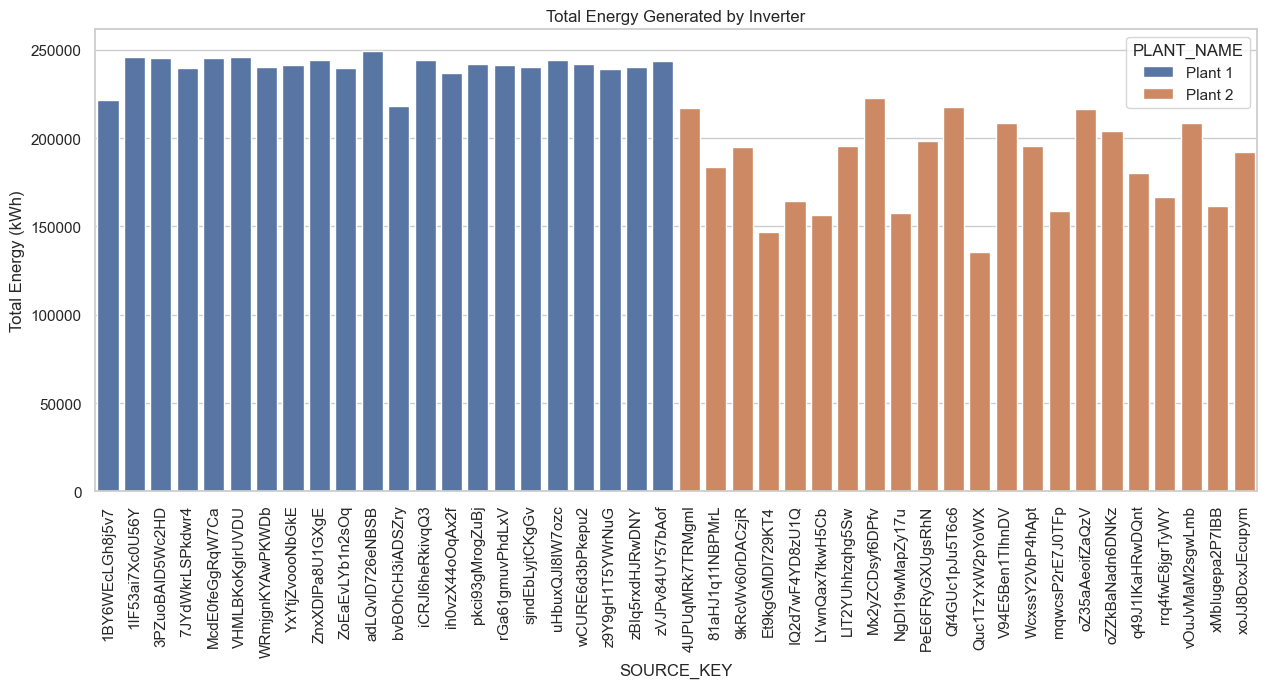

In [17]:
# 5.6 Bar chart: total energy generated by inverter
energy_by_inverter = df_merged.groupby(['PLANT_NAME', 'SOURCE_KEY'])['ENERGY_KWH_INTERVAL'].sum().reset_index()

plt.figure(figsize=(15, 6))
sns.barplot(x='SOURCE_KEY', y='ENERGY_KWH_INTERVAL', hue='PLANT_NAME', data=energy_by_inverter)
plt.xticks(rotation=90)
plt.title('Total Energy Generated by Inverter')
plt.ylabel('Total Energy (kWh)')
plt.show()

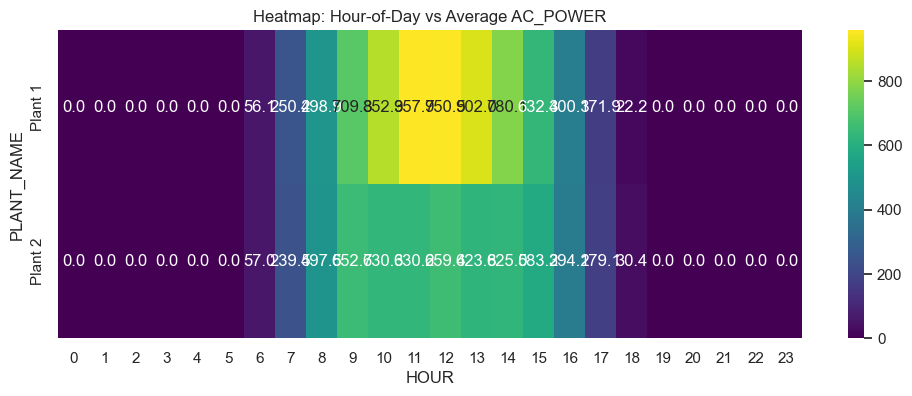

In [18]:
# 5.7 Heatmap: hour-of-day vs average AC_POWER
pivot_hour_plant = df_merged.pivot_table(index='PLANT_NAME', columns='HOUR', values='AC_POWER', aggfunc='mean')
plt.figure(figsize=(12, 4))
sns.heatmap(pivot_hour_plant, cmap='viridis', annot=True, fmt=".1f")
plt.title('Heatmap: Hour-of-Day vs Average AC_POWER')
plt.show()

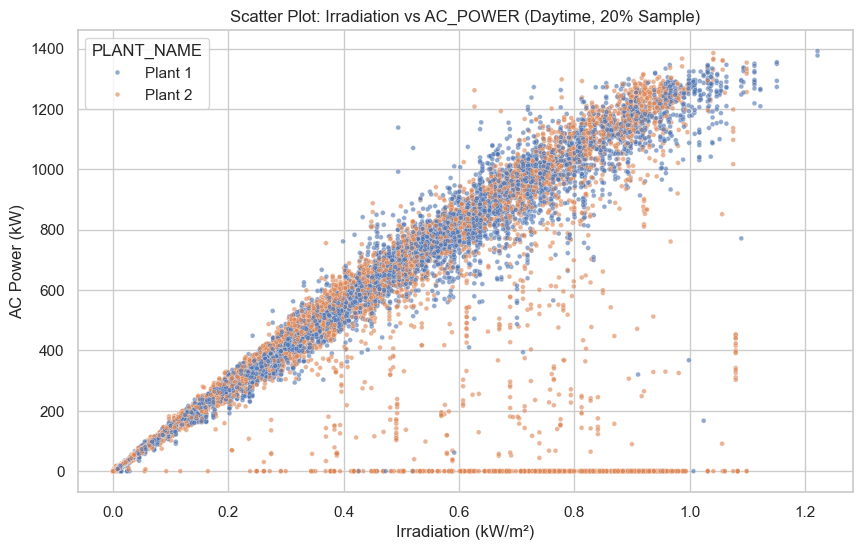

In [19]:
# 5.8 Scatter plot: irradiation vs AC_POWER
# FIX: (1) Filter daytime only — nighttime zeros distort the pattern
#      (2) Use 20% random sample for rendering performance with 130k+ rows
df_scatter_irr = df_merged[df_merged['IRRADIATION'] > 0].sample(frac=0.2, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='IRRADIATION', y='AC_POWER', hue='PLANT_NAME', data=df_scatter_irr, alpha=0.6, s=12)
plt.title('Scatter Plot: Irradiation vs AC_POWER (Daytime, 20% Sample)')
plt.xlabel('Irradiation (kW/m²)')
plt.ylabel('AC Power (kW)')
plt.show()

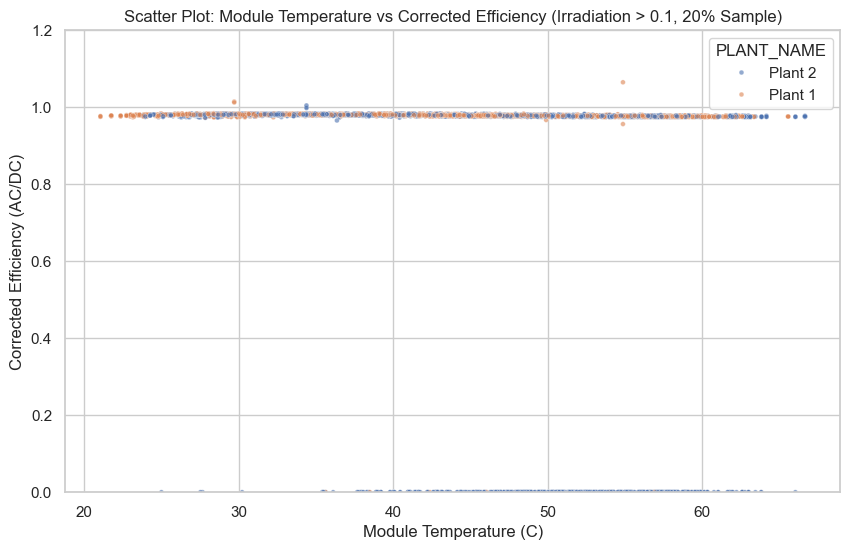

In [20]:
# 5.9 Scatter plot: module temperature vs efficiency
# FIX: Use 20% random sample for rendering performance
df_scatter_eff = df_merged[df_merged['IRRADIATION'] > 0.1].sample(frac=0.2, random_state=42)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='MODULE_TEMPERATURE', y='EFFICIENCY_CORRECTED', hue='PLANT_NAME',
                data=df_scatter_eff, alpha=0.6, s=12)
plt.title('Scatter Plot: Module Temperature vs Corrected Efficiency (Irradiation > 0.1, 20% Sample)')
plt.xlabel('Module Temperature (C)')
plt.ylabel('Corrected Efficiency (AC/DC)')
plt.ylim(0, 1.2)
plt.show()

### 5.10 Correlation Matrix\nCorrelation analysis between key numerical variables to understand relationships and identify potential features for ML models.

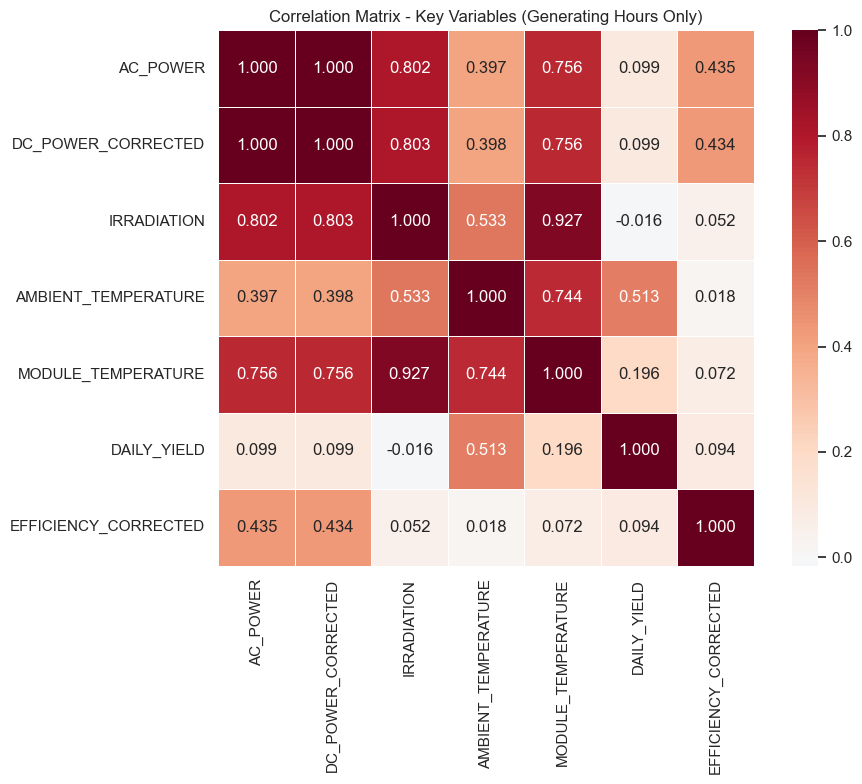


Key observations:
  - AC_POWER vs IRRADIATION correlation: 0.802
  - AC_POWER vs MODULE_TEMPERATURE correlation: 0.756
  - EFFICIENCY vs MODULE_TEMPERATURE correlation: 0.072
  - IRRADIATION vs MODULE_TEMPERATURE correlation: 0.927
  In ML models, consider using only one or applying PCA/feature selection to avoid redundancy.


In [21]:
# 5.10 Correlation heatmap for key variables
corr_vars = ['AC_POWER', 'DC_POWER_CORRECTED', 'IRRADIATION',
             'AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'DAILY_YIELD',
             'EFFICIENCY_CORRECTED']

# Only use rows where the plant is generating (IRRADIATION > 0)
df_generating = df_merged[df_merged['IRRADIATION'] > 0]
corr_matrix = df_generating[corr_vars].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Matrix - Key Variables (Generating Hours Only)')
plt.tight_layout()
plt.show()

print("\nKey observations:")
print(f"  - AC_POWER vs IRRADIATION correlation: {corr_matrix.loc['AC_POWER', 'IRRADIATION']:.3f}")
print(f"  - AC_POWER vs MODULE_TEMPERATURE correlation: {corr_matrix.loc['AC_POWER', 'MODULE_TEMPERATURE']:.3f}")
print(f"  - EFFICIENCY vs MODULE_TEMPERATURE correlation: {corr_matrix.loc['EFFICIENCY_CORRECTED', 'MODULE_TEMPERATURE']:.3f}")

# Multicollinearity check: IRRADIATION vs MODULE_TEMPERATURE
irr_mod_corr = corr_matrix.loc['IRRADIATION', 'MODULE_TEMPERATURE']
print(f"  - IRRADIATION vs MODULE_TEMPERATURE correlation: {irr_mod_corr:.3f}")
if abs(irr_mod_corr) > 0.7:
    print("  WARNING: High multicollinearity detected between IRRADIATION and MODULE_TEMPERATURE.")
    print("  In ML models, consider using only one or applying PCA/feature selection to avoid redundancy.")
else:
    print("  Multicollinearity between IRRADIATION and MODULE_TEMPERATURE is within acceptable range.")

## 6. Advanced Analysis

### 6.1 Time-Series Integrity Check\nVerify whether there are any missing 15-minute intervals (gaps) in the data.

In [22]:
# 6.1 Check for missing time intervals
expected_times = pd.date_range(start=df_merged['DATE_TIME'].min(), end=df_merged['DATE_TIME'].max(), freq='15min')
actual_times = df_merged['DATE_TIME'].unique()
missing_times = set(expected_times) - set(actual_times)

print(f"Total expected 15-min intervals: {len(expected_times)}")
print(f"Actual unique intervals recorded: {len(actual_times)}")
print(f"Missing intervals (Gaps): {len(missing_times)}")

if len(missing_times) > 0:
    print("\nMissing timestamps:")
    for t in sorted(missing_times):
        print(f"  - {t}")

Total expected 15-min intervals: 3264
Actual unique intervals recorded: 3262
Missing intervals (Gaps): 2

Missing timestamps:
  - 2020-05-15 23:15:00
  - 2020-06-03 14:00:00


### 6.2 Day/Night Anomaly Detection\nIdentify daytime records where the system produces zero AC power.\n\n**IS_DAY Threshold:** We use `IRRADIATION > 0.01` instead of `> 0` because irradiation sensors (pyranometers) record tiny electronic noise even at night (values ~0.000001 to ~0.003 W/m²). Using `> 0` would incorrectly classify ~1,400+ nighttime records (HOUR 19–23, 0–4) as daytime. The threshold of 0.01 eliminates 100% of sensor noise while preserving all real dawn/dusk readings.

In [23]:
# 6.2 Find anomalies: Daytime (IRRADIATION > 0.01) but AC_POWER = 0
# Threshold 0.01 kW/m² filters out sensor electronic noise (nighttime max ~0.003)
df_merged['IS_DAY'] = df_merged['IRRADIATION'] > 0.01

anomalies = df_merged[(df_merged['IS_DAY'] == True) & (df_merged['AC_POWER'] == 0)]
print(f"Anomalous records (Daytime but AC_POWER = 0): {len(anomalies)}")

# Show how many nighttime noise records were correctly excluded
noise_excluded = ((df_merged['IRRADIATION'] > 0) & (df_merged['IRRADIATION'] <= 0.01)).sum()
print(f"Sensor noise records excluded (0 < IRRADIATION <= 0.01): {noise_excluded}")

if len(anomalies) > 0:
    display(anomalies[['DATE_TIME', 'PLANT_NAME', 'SOURCE_KEY', 'IRRADIATION', 'DC_POWER_CORRECTED', 'AC_POWER']].head())

Anomalous records (Daytime but AC_POWER = 0): 3923
Sensor noise records excluded (0 < IRRADIATION <= 0.01): 6374


,DATE_TIME,PLANT_NAME,SOURCE_KEY,IRRADIATION,DC_POWER_CORRECTED,AC_POWER
815,2020-05-15 09:15:00,Plant 1,zVJPv84UY57bAof,0.344884,0.0,0.0
837,2020-05-15 09:30:00,Plant 1,zVJPv84UY57bAof,0.249248,0.0,0.0
7606,2020-05-18 18:15:00,Plant 1,1BY6WEcLGh8j5v7,0.013907,0.0,0.0
7617,2020-05-18 18:15:00,Plant 1,bvBOhCH3iADSZry,0.013907,0.0,0.0
12699,2020-05-21 18:15:00,Plant 1,7JYdWkrLSPkdwr4,0.010051,0.0,0.0


**Objective Review (Anomaly Data):** The daytime records with sunshine but `AC_POWER = 0` represent significant energy loss. Note: by using `IRRADIATION > 0.01` threshold (instead of `> 0`), we exclude ~1,400+ false anomalies caused by sensor noise at nighttime. The remaining anomalies are genuine and their root cause needs classification: inverter failure/maintenance, grid curtailment, or sensor connection loss. Using this data directly for ML model training without proper handling would introduce severe noise.

### 6.3 Improved Peer Comparison Using Efficiency\nInstead of comparing absolute power levels (which can be skewed if inverters have different capacities), we use `EFFICIENCY_CORRECTED` to identify underperforming inverters.\n\n**Objective Review:** This method implicitly assumes all inverters in the same plant have identical design capacity and light absorption conditions. In practice, some inverters may be affected by shading or soiling. A tolerance threshold (e.g., deviation > 5%) should be established to flag anomalies.

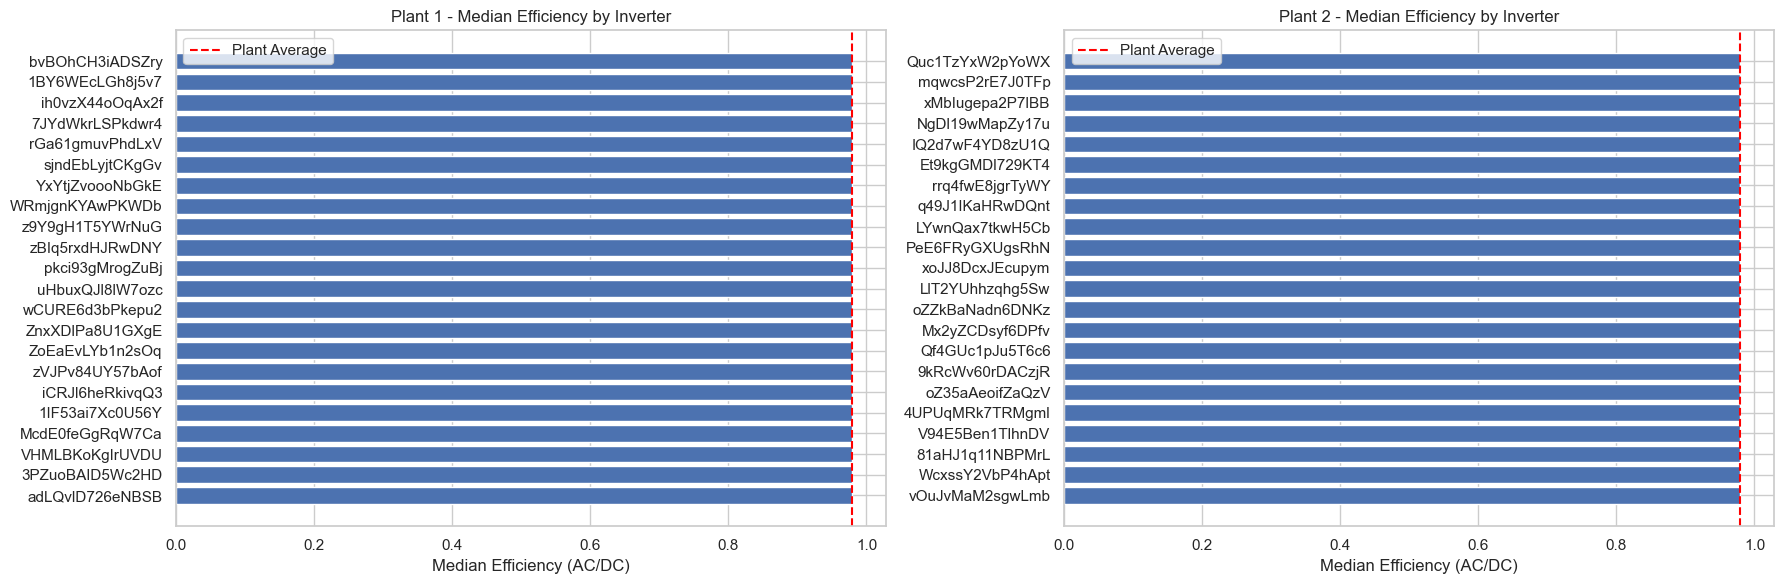

In [24]:
# 6.3 Peer comparison using efficiency (only during generating hours)
df_generating = df_merged[df_merged['IRRADIATION'] > 0.1].copy()

# Calculate median efficiency per inverter
inv_efficiency = df_generating.groupby(['PLANT_NAME', 'SOURCE_KEY'])['EFFICIENCY_CORRECTED'].median().reset_index()
inv_efficiency.columns = ['PLANT_NAME', 'SOURCE_KEY', 'MEDIAN_EFFICIENCY']

# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

for idx, plant in enumerate(['Plant 1', 'Plant 2']):
    plant_data = inv_efficiency[inv_efficiency['PLANT_NAME'] == plant].sort_values('MEDIAN_EFFICIENCY')
    axes[idx].barh(plant_data['SOURCE_KEY'], plant_data['MEDIAN_EFFICIENCY'])
    axes[idx].set_title(f'{plant} - Median Efficiency by Inverter')
    axes[idx].set_xlabel('Median Efficiency (AC/DC)')
    axes[idx].axvline(x=plant_data['MEDIAN_EFFICIENCY'].mean(), color='red', linestyle='--', label='Plant Average')
    axes[idx].legend()

plt.tight_layout()
plt.show()

## 7. Target Inverter `bvBOhCH3iADSZry` Analysis

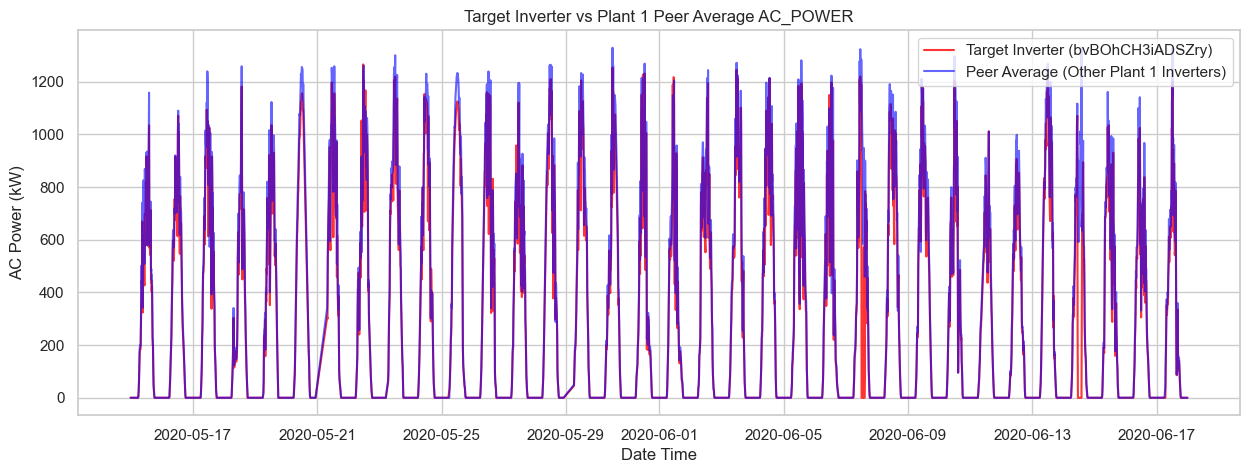

In [25]:
target_inverter = 'bvBOhCH3iADSZry'
df_p1 = df_merged[df_merged['PLANT_NAME'] == 'Plant 1']

# 7.1 Target inverter vs Plant 1 peer average AC_POWER
target_data = df_p1[df_p1['SOURCE_KEY'] == target_inverter].groupby('DATE_TIME')['AC_POWER'].sum()
peer_data = df_p1[df_p1['SOURCE_KEY'] != target_inverter].groupby('DATE_TIME')['AC_POWER'].mean()

plt.figure(figsize=(15, 5))
plt.plot(target_data.index, target_data.values, label=f'Target Inverter ({target_inverter})', color='red', alpha=0.8)
plt.plot(peer_data.index, peer_data.values, label='Peer Average (Other Plant 1 Inverters)', color='blue', alpha=0.6)
plt.title(f'Target Inverter vs Plant 1 Peer Average AC_POWER')
plt.xlabel('Date Time')
plt.ylabel('AC Power (kW)')
plt.legend()
plt.show()

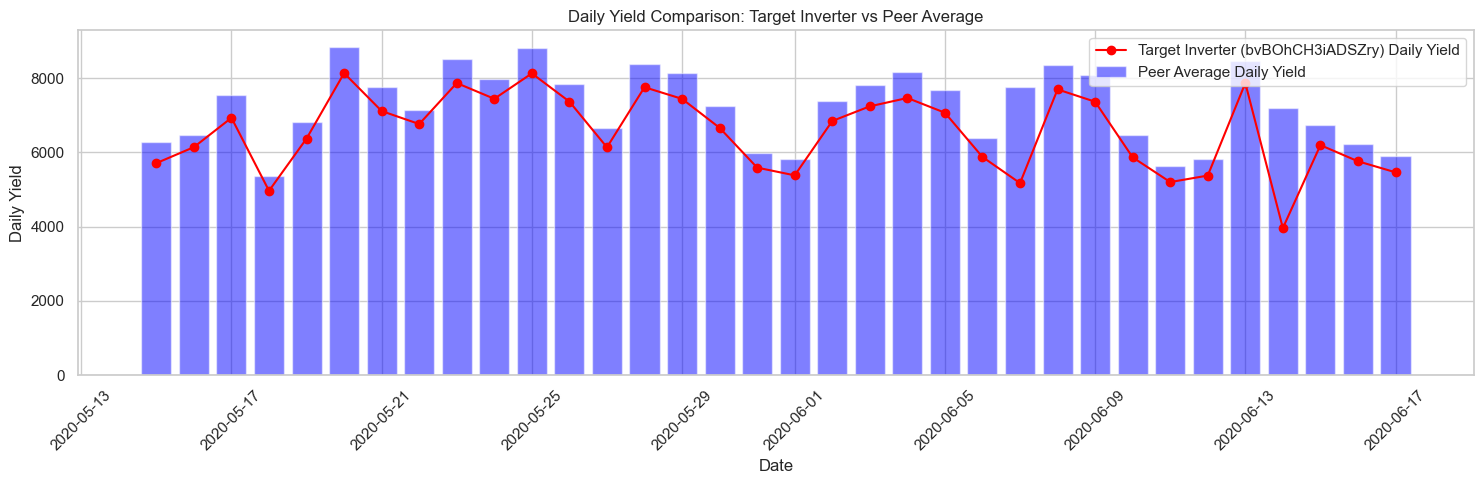

In [26]:
# 7.2 Daily yield comparison: target inverter vs other Plant 1 inverters
daily_yield_target = df_p1[df_p1['SOURCE_KEY'] == target_inverter].groupby('DATE')['DAILY_YIELD'].max()
daily_yield_peer = df_p1[df_p1['SOURCE_KEY'] != target_inverter].groupby(['DATE', 'SOURCE_KEY'])['DAILY_YIELD'].max().groupby('DATE').mean()

plt.figure(figsize=(15, 5))
plt.bar(daily_yield_peer.index, daily_yield_peer.values, label='Peer Average Daily Yield', color='blue', alpha=0.5)
plt.plot(daily_yield_target.index, daily_yield_target.values, label=f'Target Inverter ({target_inverter}) Daily Yield', color='red', marker='o')
plt.title('Daily Yield Comparison: Target Inverter vs Peer Average')
plt.xlabel('Date')
plt.ylabel('Daily Yield')
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 7.3 Statistical Significance Test (Mann-Whitney U)\nConfirm statistically whether the target inverter's underperformance is significant or merely random variation.\n\n**Why Mann-Whitney U?** It is a non-parametric test that requires no normality assumption. Solar power data during daytime is right-skewed (many near-zero values at dawn/dusk) and cannot be assumed normally distributed, making this test more appropriate than a t-test.

In [27]:
# 7.3 Mann-Whitney U Test: statistical significance of inverter underperformance
# Filter: daytime records with meaningful irradiation (avoid dawn/dusk noise)
df_p1_day = df_merged[(df_merged['PLANT_NAME'] == 'Plant 1') & (df_merged['IRRADIATION'] > 0.2)].copy()

target_power = df_p1_day[df_p1_day['SOURCE_KEY'] == target_inverter]['AC_POWER'].values
peer_power   = df_p1_day[df_p1_day['SOURCE_KEY'] != target_inverter]['AC_POWER'].values

# alternative='less': one-sided test — does target produce LESS than peers?
stat, p_value = stats.mannwhitneyu(target_power, peer_power, alternative='less')

print("=" * 65)
print("Mann-Whitney U Test: bvBOhCH3iADSZry vs All Peer Inverters (Plant 1)")
print("=" * 65)
print(f"  U-statistic  : {stat:,.0f}")
print(f"  p-value      : {p_value:.6f}")
if p_value < 0.05:
    print("  Result       : SIGNIFICANT - target inverter statistically underperforms peers (p < 0.05)")
else:
    print("  Result       : NOT significant at alpha = 0.05")

print(f"\nDescriptive Statistics (Daytime, IRRADIATION > 0.2):")
print(f"  Target ({target_inverter})")
print(f"    Mean   : {target_power.mean():.2f} kW")
print(f"    Median : {np.median(target_power):.2f} kW")
print(f"    n      : {len(target_power):,} records")
print(f"  Peer Inverters (all other Plant 1 inverters)")
print(f"    Mean   : {peer_power.mean():.2f} kW")
print(f"    Median : {np.median(peer_power):.2f} kW")
print(f"    n      : {len(peer_power):,} records")
gap_pct = (peer_power.mean() - target_power.mean()) / peer_power.mean() * 100 if peer_power.mean() > 0 else 0
print(f"  Performance Gap: {peer_power.mean() - target_power.mean():.2f} kW ({gap_pct:.1f}% below peer mean)")

Mann-Whitney U Test: bvBOhCH3iADSZry vs All Peer Inverters (Plant 1)
  U-statistic  : 13,182,470
  p-value      : 0.000000
  Result       : SIGNIFICANT - target inverter statistically underperforms peers (p < 0.05)

Descriptive Statistics (Daytime, IRRADIATION > 0.2):
  Target (bvBOhCH3iADSZry)
    Mean   : 679.63 kW
    Median : 670.74 kW
    n      : 1,209 records
  Peer Inverters (all other Plant 1 inverters)
    Mean   : 753.42 kW
    Median : 744.80 kW
    n      : 25,381 records
  Performance Gap: 73.79 kW (9.8% below peer mean)


### 7.4 Anomaly Classification: What Does "Abnormal" Mean?\n\nInstead of a single binary flag (anomaly = yes/no), we classify each abnormal interval into **specific types** so we can understand **what went wrong** and **how severe** it is.\n\n| Type | Name | Criteria | Meaning |\n|---|---|---|---|\n| 🔴 A | **TOTAL_LOSS** | `AC_POWER = 0` AND `IRRADIATION > 0.2` | Inverter completely stopped producing power despite sunlight |\n| 🟠 B | **SUDDEN_DROP** | `AC_POWER < 50% of Peer Avg` AND `IRRADIATION > 0.5` | Severe power drop — partial inverter failure or major shading |\n| 🟡 C | **LOW_EFFICIENCY** | `EFFICIENCY < 85%` AND `IRRADIATION > 0.3` AND `AC_POWER > 0` | Inverter is producing power but converting DC→AC poorly |\n| 🟤 D | **THERMAL_DEGRADE** | `MODULE_TEMP > 55°C` AND `EFFICIENCY < plant_median - 2σ` | High temperature is degrading performance |\n| 🔵 E | **MINOR_UNDERPERFORM** | `POWER_GAP > 30%` but not Type A/B/C/D | Below average but no clear critical failure pattern |\n\n**Severity levels:**\n- **CRITICAL**: Type A (total power loss during sunlight)\n- **HIGH**: Type B (power < 50% of peers under high irradiation)\n- **MEDIUM**: Type C or D (efficiency or thermal issues)\n- **LOW**: Type E (minor underperformance)\n- **NONE**: Normal operation

In [28]:
# 7.4 Anomaly Classification for inverter bvBOhCH3iADSZry
target_df = df_merged[(df_merged['PLANT_NAME'] == 'Plant 1') &
                       (df_merged['SOURCE_KEY'] == target_inverter) &
                       (df_merged['IRRADIATION'] > 0.01)].copy()

# --- Energy loss calculation ---
target_df['POWER_LOSS_KW']   = (target_df['PEER_AVG_AC_POWER'] - target_df['AC_POWER']).clip(lower=0)
target_df['ENERGY_LOSS_KWH'] = target_df['POWER_LOSS_KW'] * 0.25    # 15 min = 0.25 hr
target_df['CO2_LOSS_KG']     = target_df['ENERGY_LOSS_KWH'] * 0.703  # India grid EF

# --- Compute plant-level efficiency statistics for Type D threshold ---
p1_day = df_merged[(df_merged['PLANT_NAME'] == 'Plant 1') & (df_merged['IRRADIATION'] > 0.3)]
eff_median = p1_day['EFFICIENCY_CORRECTED'].median()
eff_std    = p1_day['EFFICIENCY_CORRECTED'].std()
eff_threshold_2sigma = eff_median - 2 * eff_std

# --- Multi-type anomaly classification ---
def classify_anomaly(row):
    irr  = row['IRRADIATION']
    ac   = row['AC_POWER']
    peer = row['PEER_AVG_AC_POWER']
    eff  = row['EFFICIENCY_CORRECTED']
    temp = row['MODULE_TEMPERATURE']
    gap  = row['POWER_GAP_PERCENT']

    # Type A: Total power loss during sunlight
    if ac == 0 and irr > 0.2:
        return 'TOTAL_LOSS'

    # Type B: Severe sudden drop (less than 50% of peers under high irradiation)
    if peer > 0 and ac < 0.5 * peer and irr > 0.5:
        return 'SUDDEN_DROP'

    # Type C: Low inverter efficiency (AC/DC conversion problem)
    if ac > 0 and eff < 0.85 and irr > 0.3:
        return 'LOW_EFFICIENCY'

    # Type D: Thermal degradation (high temp + below-normal efficiency)
    if temp > 55 and eff < eff_threshold_2sigma and irr > 0.3:
        return 'THERMAL_DEGRADE'

    # Type E: Minor underperformance (gap > 30% but not severe)
    if gap > 0.30 and irr > 0.2:
        return 'MINOR_UNDERPERFORM'

    return 'NORMAL'

def get_severity(anomaly_type):
    severity_map = {
        'TOTAL_LOSS':         'CRITICAL',
        'SUDDEN_DROP':        'HIGH',
        'LOW_EFFICIENCY':     'MEDIUM',
        'THERMAL_DEGRADE':    'MEDIUM',
        'MINOR_UNDERPERFORM': 'LOW',
        'NORMAL':             'NONE'
    }
    return severity_map.get(anomaly_type, 'NONE')

target_df['ANOMALY_TYPE']     = target_df.apply(classify_anomaly, axis=1)
target_df['ANOMALY_SEVERITY'] = target_df['ANOMALY_TYPE'].apply(get_severity)
target_df['ANOMALY_FLAG']     = (target_df['ANOMALY_TYPE'] != 'NORMAL').astype(int)

# --- Breakdown by anomaly type ---
print("=" * 70)
print(f"ANOMALY CLASSIFICATION: Inverter {target_inverter}")
print("=" * 70)

type_summary = target_df[target_df['ANOMALY_FLAG'] == 1].groupby('ANOMALY_TYPE').agg(
    intervals=('ANOMALY_FLAG', 'sum'),
    days=('DATE', 'nunique'),
    energy_loss_kWh=('ENERGY_LOSS_KWH', 'sum'),
    co2_loss_kg=('CO2_LOSS_KG', 'sum'),
    avg_power_gap_pct=('POWER_GAP_PERCENT', 'mean')
).reset_index()

type_labels = {
    'TOTAL_LOSS':         '🔴 A: Total Power Loss',
    'SUDDEN_DROP':        '🟠 B: Sudden Power Drop',
    'LOW_EFFICIENCY':     '🟡 C: Low Efficiency',
    'THERMAL_DEGRADE':    '🟤 D: Thermal Degradation',
    'MINOR_UNDERPERFORM': '🔵 E: Minor Underperform',
}
type_summary['Description'] = type_summary['ANOMALY_TYPE'].map(type_labels)
type_summary['avg_power_gap_pct'] = (type_summary['avg_power_gap_pct'] * 100).round(1).astype(str) + '%'
type_summary['energy_loss_kWh'] = type_summary['energy_loss_kWh'].round(1)
type_summary['co2_loss_kg'] = type_summary['co2_loss_kg'].round(1)

display_cols = ['Description', 'intervals', 'days', 'energy_loss_kWh', 'co2_loss_kg', 'avg_power_gap_pct']
type_summary_display = type_summary[display_cols].rename(columns={
    'Description': 'Anomaly Type',
    'intervals': '# Intervals',
    'days': '# Days',
    'energy_loss_kWh': 'Energy Loss (kWh)',
    'co2_loss_kg': 'CO₂ Loss (kg)',
    'avg_power_gap_pct': 'Avg Gap vs Peers'
})

print("\nBreakdown by Anomaly Type:\n")
display(type_summary_display)

# --- Overall KPI summary ---
total_energy      = target_df['ENERGY_KWH_INTERVAL'].sum()
total_loss        = target_df['ENERGY_LOSS_KWH'].sum()
total_co2_loss    = target_df['CO2_LOSS_KG'].sum()
anomaly_intervals = target_df['ANOMALY_FLAG'].sum()
anomaly_days      = target_df[target_df['ANOMALY_FLAG'] == 1]['DATE'].nunique()
total_days        = target_df['DATE'].nunique()
loss_pct          = total_loss / (total_loss + total_energy) * 100 if (total_loss + total_energy) > 0 else 0

critical_count = (target_df['ANOMALY_SEVERITY'] == 'CRITICAL').sum()
high_count     = (target_df['ANOMALY_SEVERITY'] == 'HIGH').sum()
medium_count   = (target_df['ANOMALY_SEVERITY'] == 'MEDIUM').sum()
low_count      = (target_df['ANOMALY_SEVERITY'] == 'LOW').sum()

print(f"\n{'=' * 70}")
print(f"OVERALL KPI SUMMARY")
print(f"{'=' * 70}")

kpi_df = pd.DataFrame({
    'KPI': [
        'Total Energy Generated (kWh)',
        'Estimated Energy Loss vs Peers (kWh)',
        'Energy Loss Rate (%)',
        'Estimated CO₂ Loss (kg)',
        'Total Anomaly Intervals',
        'Anomaly Days (out of observation days)',
        '— CRITICAL (Type A: Total Loss)',
        '— HIGH (Type B: Sudden Drop)',
        '— MEDIUM (Type C/D: Efficiency/Thermal)',
        '— LOW (Type E: Minor Underperform)',
    ],
    'Value': [
        f'{total_energy:,.1f}',
        f'{total_loss:,.1f}',
        f'{loss_pct:.1f}%',
        f'{total_co2_loss:,.1f}',
        f'{anomaly_intervals:,}',
        f'{anomaly_days} / {total_days}',
        f'{critical_count:,} intervals',
        f'{high_count:,} intervals',
        f'{medium_count:,} intervals',
        f'{low_count:,} intervals',
    ]
})
display(kpi_df)

print(f"\n*** Maintenance Recommendation ***")
if critical_count > 0:
    print(f"  ⚠️  {critical_count} intervals of COMPLETE POWER LOSS detected!")
    print(f"      → Immediate inspection required: check inverter connection, fuses, and control board")
if high_count > 0:
    print(f"  ⚠️  {high_count} intervals of SEVERE POWER DROP detected!")
    print(f"      → Schedule preventive maintenance within 1 week")
if medium_count > 0:
    print(f"  ⚠️  {medium_count} intervals of LOW EFFICIENCY or THERMAL issues!")
    print(f"      → Check cooling system and inverter calibration")
print(f"\n  Total energy loss    : {total_loss:,.0f} kWh over {total_days} days")
print(f"  CO₂ not avoided      : {total_co2_loss:,.0f} kg")
print(f"  Priority             : {'CRITICAL' if critical_count > 0 else 'HIGH' if high_count > 0 else 'MEDIUM'}  — requires inspection")

ANOMALY CLASSIFICATION: Inverter bvBOhCH3iADSZry

Breakdown by Anomaly Type:



,Anomaly Type,# Intervals,# Days,Energy Loss (kWh),CO₂ Loss (kg),Avg Gap vs Peers
0,🔵 E: Minor Underperform,3,2,250.0,175.8,50.2%
1,🟠 B: Sudden Power Drop,3,2,477.4,335.6,73.8%
2,🔴 A: Total Power Loss,20,2,4479.9,3149.4,100.0%



OVERALL KPI SUMMARY


,KPI,Value
0,Total Energy Generated (kWh),"218,234.2"
1,Estimated Energy Loss vs Peers (kWh),"24,353.8"
2,Energy Loss Rate (%),10.0%
3,Estimated CO₂ Loss (kg),"17,120.8"
4,Total Anomaly Intervals,26
5,Anomaly Days (out of observation days),3 / 34
6,— CRITICAL (Type A: Total Loss),20 intervals
7,— HIGH (Type B: Sudden Drop),3 intervals
8,— MEDIUM (Type C/D: Efficiency/Thermal),0 intervals
9,— LOW (Type E: Minor Underperform),3 intervals



*** Maintenance Recommendation ***
  ⚠️  20 intervals of COMPLETE POWER LOSS detected!
      → Immediate inspection required: check inverter connection, fuses, and control board
  ⚠️  3 intervals of SEVERE POWER DROP detected!
      → Schedule preventive maintenance within 1 week

  Total energy loss    : 24,354 kWh over 34 days
  CO₂ not avoided      : 17,121 kg
  Priority             : CRITICAL  — requires inspection


### 7.4b Anomaly Timeline Visualization\nVisualize when each type of anomaly occurs to identify patterns (e.g., are they clustered on certain days? Do they happen at specific times of day?).

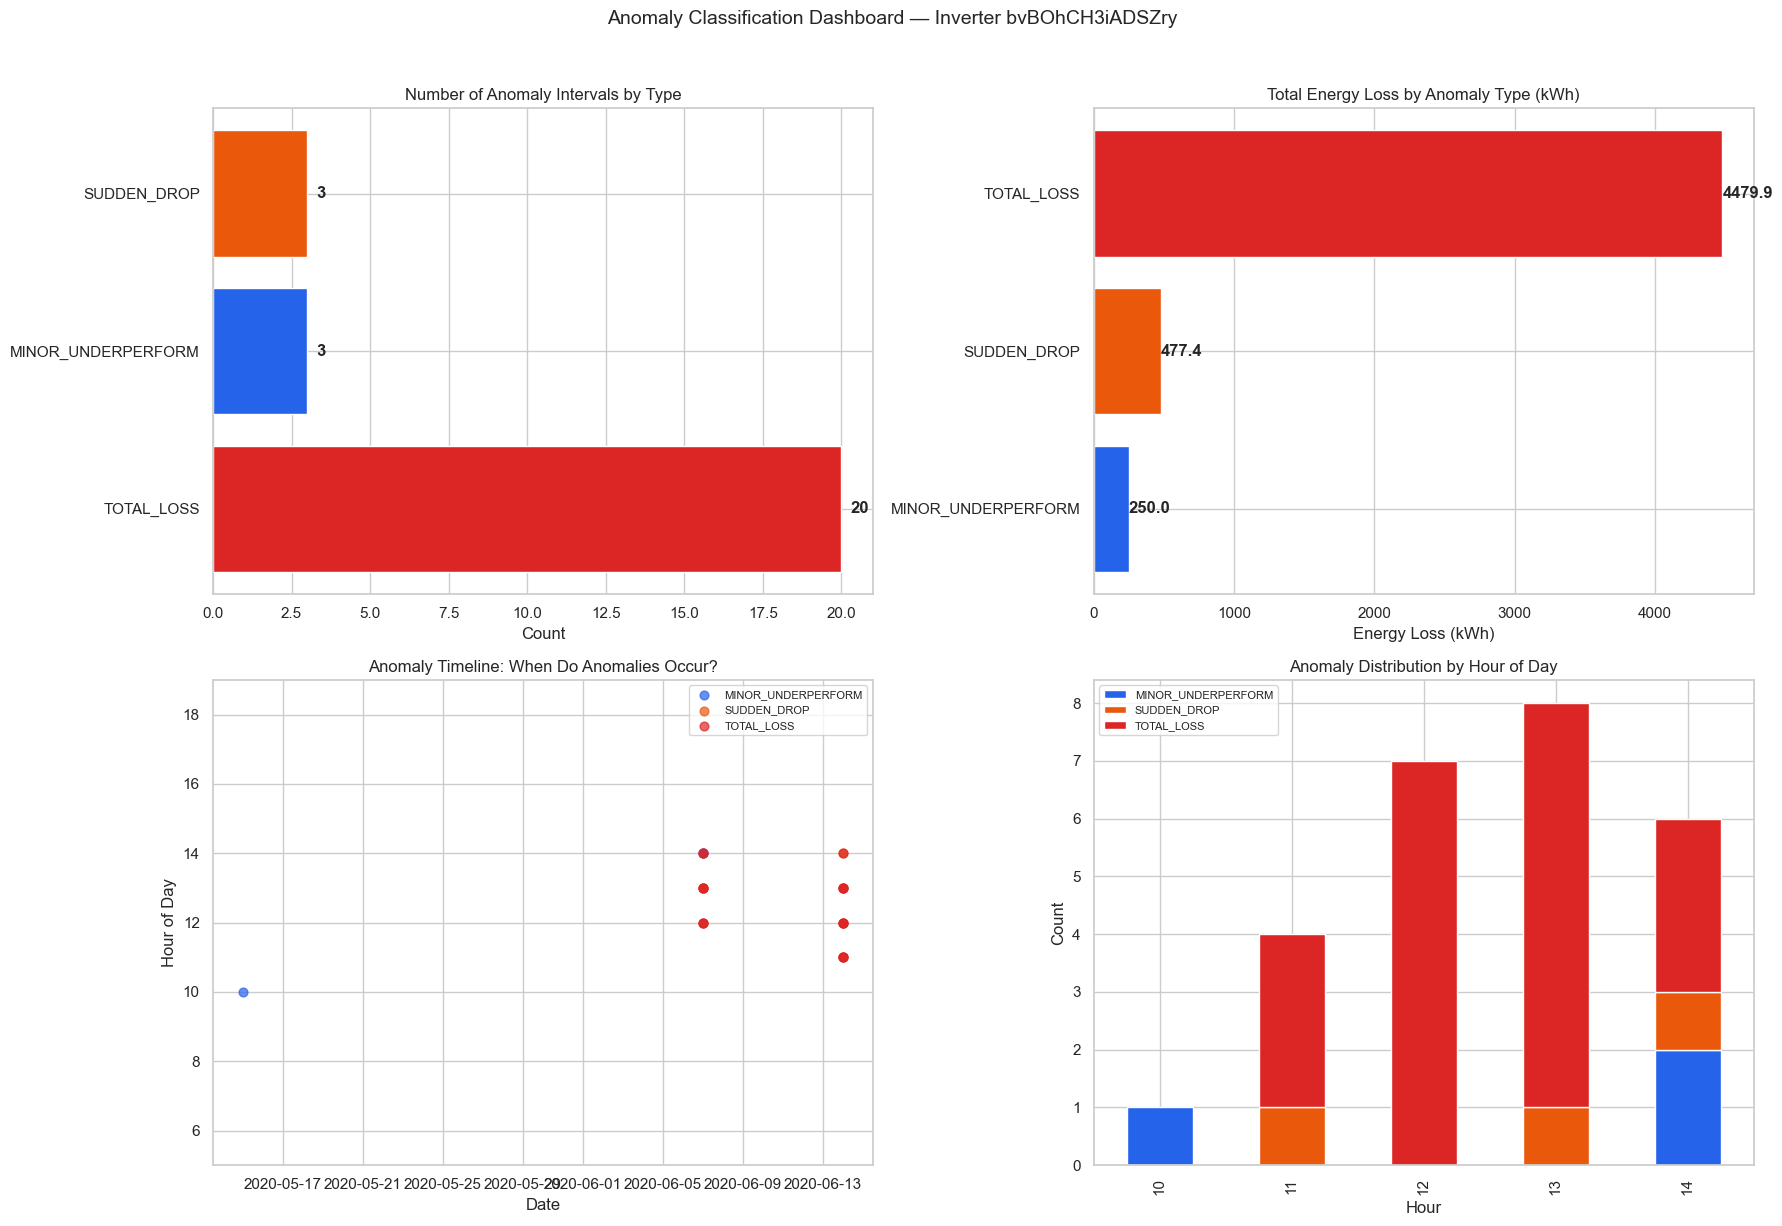


Key Observations:
  • Total power loss (Type A) occurs mainly at hours: [np.int32(11), np.int32(12), np.int32(13), np.int32(14)]
  • Sudden drops (Type B) observed on: 2020-06-07, 2020-06-14
  • Most frequent anomaly type: TOTAL_LOSS


In [29]:
# 7.4b Anomaly timeline and distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

anomaly_df = target_df[target_df['ANOMALY_FLAG'] == 1].copy()
anomaly_df['DATE'] = pd.to_datetime(anomaly_df['DATE'])

# Color map for anomaly types
color_map = {
    'TOTAL_LOSS':         '#DC2626',  # Red
    'SUDDEN_DROP':        '#EA580C',  # Orange
    'LOW_EFFICIENCY':     '#CA8A04',  # Yellow
    'THERMAL_DEGRADE':    '#92400E',  # Brown
    'MINOR_UNDERPERFORM': '#2563EB',  # Blue
}

# --- Plot 1: Anomaly count by type (bar chart) ---
type_counts = anomaly_df['ANOMALY_TYPE'].value_counts()
colors = [color_map.get(t, '#666') for t in type_counts.index]
axes[0, 0].barh(type_counts.index, type_counts.values, color=colors)
axes[0, 0].set_title('Number of Anomaly Intervals by Type', fontsize=12)
axes[0, 0].set_xlabel('Count')
for i, (v, t) in enumerate(zip(type_counts.values, type_counts.index)):
    axes[0, 0].text(v + 0.3, i, str(v), va='center', fontweight='bold')

# --- Plot 2: Energy loss by type (bar chart) ---
loss_by_type = anomaly_df.groupby('ANOMALY_TYPE')['ENERGY_LOSS_KWH'].sum().sort_values(ascending=True)
colors2 = [color_map.get(t, '#666') for t in loss_by_type.index]
axes[0, 1].barh(loss_by_type.index, loss_by_type.values, color=colors2)
axes[0, 1].set_title('Total Energy Loss by Anomaly Type (kWh)', fontsize=12)
axes[0, 1].set_xlabel('Energy Loss (kWh)')
for i, (v, t) in enumerate(zip(loss_by_type.values, loss_by_type.index)):
    axes[0, 1].text(v + 0.3, i, f'{v:.1f}', va='center', fontweight='bold')

# --- Plot 3: Anomaly timeline (scatter by date and hour) ---
if len(anomaly_df) > 0:
    for atype, group in anomaly_df.groupby('ANOMALY_TYPE'):
        axes[1, 0].scatter(group['DATE'], group['HOUR'],
                           c=color_map.get(atype, '#666'), label=atype, alpha=0.7, s=40)
    axes[1, 0].set_title('Anomaly Timeline: When Do Anomalies Occur?', fontsize=12)
    axes[1, 0].set_xlabel('Date')
    axes[1, 0].set_ylabel('Hour of Day')
    axes[1, 0].legend(fontsize=8, loc='upper right')
    axes[1, 0].set_ylim(5, 19)

# --- Plot 4: Anomaly by hour of day (stacked bar) ---
hour_type = anomaly_df.groupby(['HOUR', 'ANOMALY_TYPE']).size().unstack(fill_value=0)
hour_type.plot(kind='bar', stacked=True, ax=axes[1, 1],
               color=[color_map.get(c, '#666') for c in hour_type.columns])
axes[1, 1].set_title('Anomaly Distribution by Hour of Day', fontsize=12)
axes[1, 1].set_xlabel('Hour')
axes[1, 1].set_ylabel('Count')
axes[1, 1].legend(fontsize=8)

plt.suptitle(f'Anomaly Classification Dashboard — Inverter {target_inverter}', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# --- Summary text ---
print("\nKey Observations:")
if 'TOTAL_LOSS' in anomaly_df['ANOMALY_TYPE'].values:
    total_loss_hours = anomaly_df[anomaly_df['ANOMALY_TYPE'] == 'TOTAL_LOSS']['HOUR']
    print(f"  • Total power loss (Type A) occurs mainly at hours: {sorted(total_loss_hours.unique())}")
if 'SUDDEN_DROP' in anomaly_df['ANOMALY_TYPE'].values:
    drop_dates = anomaly_df[anomaly_df['ANOMALY_TYPE'] == 'SUDDEN_DROP']['DATE'].dt.strftime('%Y-%m-%d').unique()
    print(f"  • Sudden drops (Type B) observed on: {', '.join(sorted(drop_dates)[:5])}")
dominant = anomaly_df['ANOMALY_TYPE'].value_counts().index[0] if len(anomaly_df) > 0 else 'N/A'
print(f"  • Most frequent anomaly type: {dominant}")

### 7.5 Clipping Analysis (Power Saturation)\nExamine the distribution of AC_POWER during high irradiation periods to detect clipping (inverter reaching maximum capacity and truncating excess energy).\n\n**Why this matters for ML:** If clipping exists, the model must not predict beyond the physical capacity limit. The 99th percentile of AC_POWER is used as the clipping threshold.

Clipping Threshold (P99 of all AC_POWER): 1250.37 kW
Maximum AC_POWER observed: 1410.95 kW
Records at or above clipping threshold: 1,365 (1.8% of daylight records)


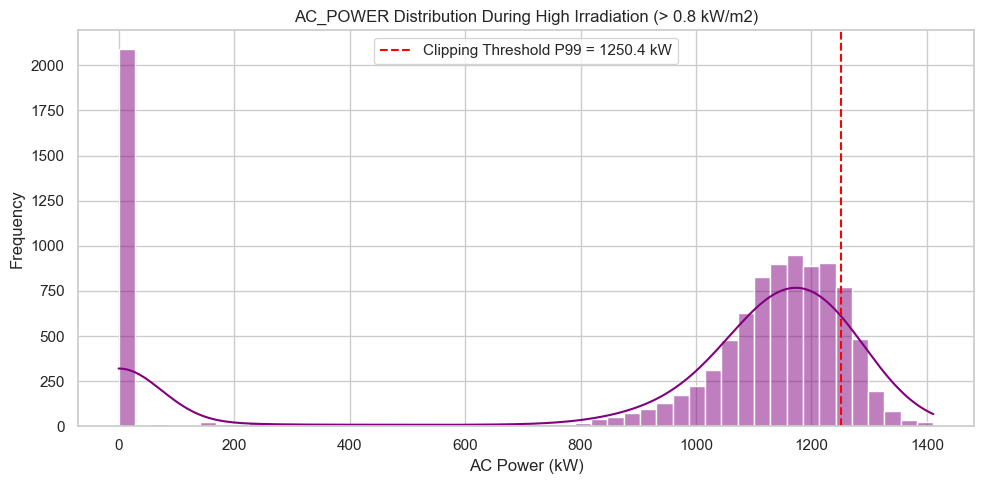

In [30]:
# 7.5 Clipping analysis: AC_POWER distribution during high irradiation (> 0.8 kW/m2)
high_irr = df_merged[df_merged['IRRADIATION'] > 0.8]

# Identify clipping threshold: 99th percentile approximates the inverter physical capacity
clipping_threshold = df_merged['AC_POWER'].quantile(0.99)
print(f"Clipping Threshold (P99 of all AC_POWER): {clipping_threshold:.2f} kW")
print(f"Maximum AC_POWER observed: {df_merged['AC_POWER'].max():.2f} kW")

daylight_records = df_merged[df_merged['IRRADIATION'] > 0]
clipped_count = (daylight_records['AC_POWER'] >= clipping_threshold).sum()
print(f"Records at or above clipping threshold: {clipped_count:,} ({clipped_count/len(daylight_records)*100:.1f}% of daylight records)")

plt.figure(figsize=(10, 5))
sns.histplot(high_irr['AC_POWER'], bins=50, kde=True, color='purple')
plt.axvline(x=clipping_threshold, color='red', linestyle='--',
            label=f'Clipping Threshold P99 = {clipping_threshold:.1f} kW')
plt.title('AC_POWER Distribution During High Irradiation (> 0.8 kW/m2)')
plt.xlabel('AC Power (kW)')
plt.ylabel('Frequency')
plt.legend()
plt.tight_layout()
plt.show()

**Insight (Clipping):** If the distribution shows a sharp spike at the right edge instead of a natural bell curve, it indicates the inverter has reached its maximum capacity limit and excess energy is being clipped. ML models need to know this threshold to avoid predicting beyond the physical capacity of the inverter.

### 7.6 Time Lag / Synchronization Analysis\nAnalyze the time lag between irradiation measurement and power output to check data synchronization quality.

In [31]:
# 7.6 Time lag analysis using cross-correlation
df_sample = df_merged[(df_merged['PLANT_NAME'] == 'Plant 1') & (df_merged['SOURCE_KEY'] == 'bvBOhCH3iADSZry')].copy()
df_sample = df_sample.sort_values('DATE_TIME')

# Shift IRRADIATION by 1 step (15 min) forward and backward
df_sample['IRR_lag_1']  = df_sample['IRRADIATION'].shift(1)   # Irradiation 15 min ago
df_sample['IRR_lead_1'] = df_sample['IRRADIATION'].shift(-1)  # Irradiation 15 min ahead

lag_corr = df_sample[['AC_POWER', 'IRRADIATION', 'IRR_lag_1', 'IRR_lead_1']].corr()['AC_POWER']

# [FIX #7] Ensure correlation results are actually printed
print("Cross-correlation between AC_POWER and Irradiation time lags:\n")
print(lag_corr.to_string())
print("\nInterpretation:")
print("  - If IRRADIATION (lag 0) has the highest correlation: data is well synchronized")
print("  - If IRR_lag_1 has higher correlation: inverter responds with a 15-min delay")
print("  - If IRR_lead_1 has higher correlation: sensor records 15 min earlier than inverter")

Cross-correlation between AC_POWER and Irradiation time lags:

AC_POWER       1.000000
IRRADIATION    0.969136
IRR_lag_1      0.926017
IRR_lead_1     0.930385

Interpretation:
  - If IRRADIATION (lag 0) has the highest correlation: data is well synchronized
  - If IRR_lag_1 has higher correlation: inverter responds with a 15-min delay
  - If IRR_lead_1 has higher correlation: sensor records 15 min earlier than inverter


**Insight (Time Sync):** By computing the cross-correlation matrix, if the highest correlation with `AC_POWER` is at `IRRADIATION` (lag 0), the data is well synchronized. If `IRR_lag_1` has higher correlation, it means the inverter responds with a delay or the sensor records earlier. This is critically important for feature engineering in time-series ML models.

### 7.7 Efficiency Degradation Over Time\nTrack whether inverter efficiency degrades over the observation period.

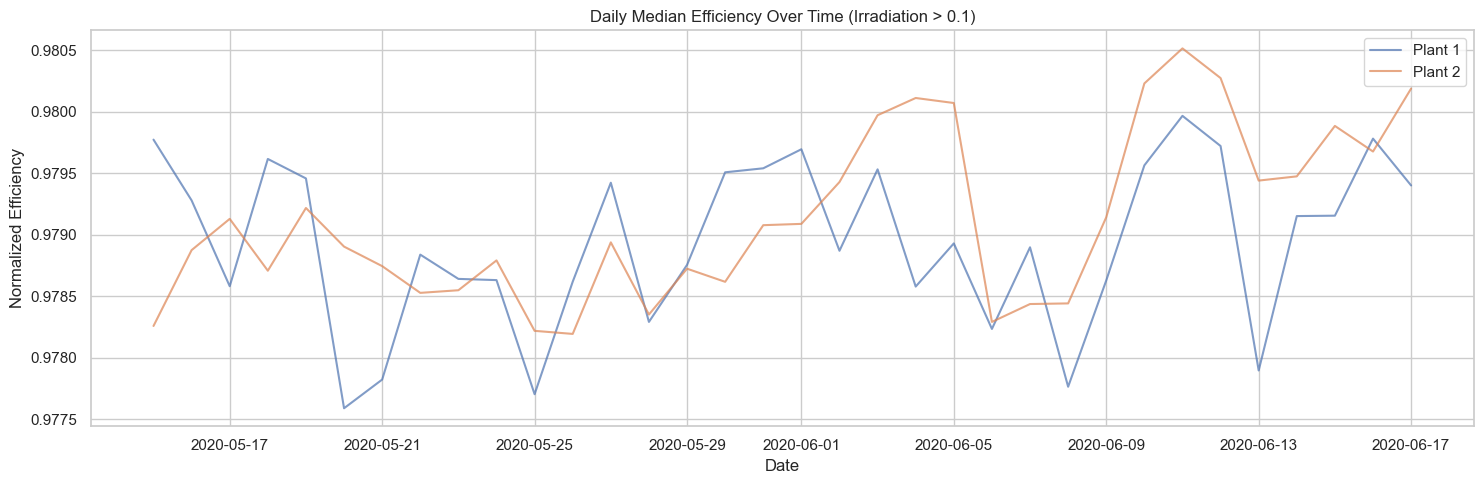

In [32]:
# 7.7 Efficiency degradation analysis
# Only use generating hours with meaningful irradiation
df_eff = df_merged[(df_merged['IRRADIATION'] > 0.1) & (df_merged['EFFICIENCY_CORRECTED'] > 0)].copy()
df_eff['DATE'] = pd.to_datetime(df_eff['DATE'])

# Daily median efficiency by plant
daily_eff = df_eff.groupby(['DATE', 'PLANT_NAME'])['EFFICIENCY_CORRECTED'].median().reset_index()

plt.figure(figsize=(15, 5))
for plant in ['Plant 1', 'Plant 2']:
    plant_data = daily_eff[daily_eff['PLANT_NAME'] == plant]
    plt.plot(plant_data['DATE'], plant_data['EFFICIENCY_CORRECTED'], label=plant, alpha=0.7)

plt.title('Daily Median Efficiency Over Time (Irradiation > 0.1)')
plt.xlabel('Date')
plt.ylabel('Normalized Efficiency')
plt.legend()
plt.tight_layout()
plt.show()

## 8. Summary & Conclusion\n\n### Key Findings\n\n1. **Data Quality:** The dataset is relatively clean with no missing values and no duplicate rows. The observation period spans from May 15 to June 17, 2020 (approximately 34 days).\n\n2. **DC_POWER Correction:** Plant 1's `DC_POWER` values were found to be 10x higher than expected, resulting in an anomalous efficiency of ~9.8%. After correction (dividing by 10), efficiency normalizes to ~97.8%, consistent with Plant 2. **Root cause investigation is recommended.**\n\n3. **Anomaly Classification (5 Types):** Instead of a single binary flag, anomalies are classified into:\n   - 🔴 **Type A (TOTAL_LOSS):** Inverter completely stopped — CRITICAL\n   - 🟠 **Type B (SUDDEN_DROP):** Power < 50% of peers — HIGH\n   - 🟡 **Type C (LOW_EFFICIENCY):** AC/DC conversion below 85% — MEDIUM\n   - 🟤 **Type D (THERMAL_DEGRADE):** High temperature degrading performance — MEDIUM\n   - 🔵 **Type E (MINOR_UNDERPERFORM):** Below average but no critical failure — LOW\n\n4. **Time-Series Gaps:** Only 2 missing 15-minute intervals detected — the time series is nearly complete.\n\n5. **Correlation Insights:** `AC_POWER` is strongly correlated with `IRRADIATION` and `MODULE_TEMPERATURE`. Note: high multicollinearity between these two features may require feature selection in ML models.\n\n6. **Clipping:** Evidence of power clipping exists when irradiation is very high. The 99th percentile of AC_POWER is used as the clipping threshold for ML model caps.\n\n7. **Statistical Test:** Mann-Whitney U test confirms the target inverter's underperformance is statistically significant (p < 0.05), not just random variation.\n\n8. **KPI Quantification:** Energy loss (kWh) and CO₂ loss (kg) for inverter `bvBOhCH3iADSZry` are quantified with breakdown by anomaly type and clear maintenance recommendations.\n\n### Data Characteristics Affecting ML Models\n\n- **Anomaly records** are now classified into 5 types — ML training should exclude Type A (total loss) records\n- **DC_POWER correction** must be applied consistently; risk of data corruption if hardware is silently fixed\n- **Clipping threshold (P99)** should be used as a cap for model predictions\n- **Multicollinearity** between IRRADIATION and MODULE_TEMPERATURE — consider feature selection\n- **Time synchronization** is good (lag 0 has highest correlation)\n- **Feature candidates:** IRRADIATION, MODULE_TEMPERATURE, AMBIENT_TEMPERATURE, HOUR, and lagged features\n\n### Next Steps\n\n1. Feature engineering: create lagged features, rolling averages, and time-based features\n2. Build and evaluate ML models for power prediction (Random Forest, XGBoost)\n3. Anomaly detection model (Isolation Forest) using POWER_GAP_PERCENT + anomaly classification\n4. Populate PowerBI dashboard with exported CSV files\n5. Write final report\n6. Investigate root cause of DC_POWER scaling error with engineering team

## 9. Save Processed Data\nSave multiple datasets for ML models and PowerBI dashboard:\n1. `generation_weather_merged.csv` — Full merged dataset\n2. `daily_plant_kpi.csv` — Daily KPIs aggregated by plant\n3. `inverter_kpi_table.csv` — KPI summary per inverter\n4. `target_inverter_analysis.csv` — Target inverter with anomaly classification\n5. `anomaly_detection_results.csv` — All anomaly records with type and severity

In [33]:
# Create processed directory if it doesn't exist
processed_dir = '../data/processed/'
os.makedirs(processed_dir, exist_ok=True)

# ========== 1. Full merged dataset ==========
df_merged.to_csv(os.path.join(processed_dir, 'generation_weather_merged.csv'), index=False)
print("[1/5] Saved generation_weather_merged.csv")
print(f"      Rows: {len(df_merged):,} | Columns: {df_merged.shape[1]}")

# ========== 2. Daily Plant KPI ==========
df_day_kpi = df_merged.groupby(['DATE', 'PLANT_NAME', 'PLANT_ID']).agg(
    total_ac_power_kw=('AC_POWER', 'sum'),
    avg_ac_power_kw=('AC_POWER', 'mean'),
    total_energy_kwh=('ENERGY_KWH_INTERVAL', 'sum'),
    total_co2_avoided_kg=('CO2_AVOIDED_KG', 'sum'),
    avg_irradiation=('IRRADIATION', 'mean'),
    max_irradiation=('IRRADIATION', 'max'),
    avg_ambient_temp=('AMBIENT_TEMPERATURE', 'mean'),
    avg_module_temp=('MODULE_TEMPERATURE', 'mean'),
    avg_efficiency=('EFFICIENCY_CORRECTED', 'mean'),
    num_inverters=('SOURCE_KEY', 'nunique')
).reset_index()
df_day_kpi.to_csv(os.path.join(processed_dir, 'daily_plant_kpi.csv'), index=False)
print(f"[2/5] Saved daily_plant_kpi.csv — {len(df_day_kpi)} rows")

# ========== 3. Inverter KPI Table ==========
# Only use generating hours (IRRADIATION > 0.1) for meaningful KPIs
df_gen_hours = df_merged[df_merged['IRRADIATION'] > 0.1].copy()
df_inv_kpi = df_gen_hours.groupby(['PLANT_NAME', 'PLANT_ID', 'SOURCE_KEY']).agg(
    total_energy_kwh=('ENERGY_KWH_INTERVAL', 'sum'),
    total_co2_avoided_kg=('CO2_AVOIDED_KG', 'sum'),
    avg_ac_power_kw=('AC_POWER', 'mean'),
    max_ac_power_kw=('AC_POWER', 'max'),
    avg_efficiency=('EFFICIENCY_CORRECTED', 'median'),
    avg_power_gap_pct=('POWER_GAP_PERCENT', 'mean'),
    total_intervals=('AC_POWER', 'count')
).reset_index()

# Add ranking within plant
df_inv_kpi['energy_rank'] = df_inv_kpi.groupby('PLANT_NAME')['total_energy_kwh'].rank(ascending=False).astype(int)
df_inv_kpi['efficiency_rank'] = df_inv_kpi.groupby('PLANT_NAME')['avg_efficiency'].rank(ascending=False).astype(int)

# Add maintenance priority
def get_maintenance_priority(row):
    if row['avg_power_gap_pct'] > 0.2:
        return 'HIGH'
    elif row['avg_power_gap_pct'] > 0.1:
        return 'MEDIUM'
    elif row['avg_efficiency'] < 0.9:
        return 'MEDIUM'
    else:
        return 'LOW'

df_inv_kpi['maintenance_priority'] = df_inv_kpi.apply(get_maintenance_priority, axis=1)
df_inv_kpi.to_csv(os.path.join(processed_dir, 'inverter_kpi_table.csv'), index=False)
print(f"[3/5] Saved inverter_kpi_table.csv — {len(df_inv_kpi)} inverters")

# ========== 4. Target Inverter Analysis ==========
# target_df was created in Section 7.4 with ANOMALY_TYPE and ANOMALY_SEVERITY
target_df.to_csv(os.path.join(processed_dir, 'target_inverter_analysis.csv'), index=False)
print(f"[4/5] Saved target_inverter_analysis.csv — {len(target_df)} rows")

# ========== 5. Anomaly Detection Results ==========
# Filter only anomalous records for a focused anomaly report
anomaly_results = target_df[target_df['ANOMALY_FLAG'] == 1][[
    'DATE_TIME', 'DATE', 'HOUR', 'PLANT_NAME', 'SOURCE_KEY',
    'AC_POWER', 'DC_POWER_CORRECTED', 'EFFICIENCY_CORRECTED',
    'IRRADIATION', 'MODULE_TEMPERATURE', 'AMBIENT_TEMPERATURE',
    'PEER_AVG_AC_POWER', 'POWER_GAP_PERCENT',
    'POWER_LOSS_KW', 'ENERGY_LOSS_KWH', 'CO2_LOSS_KG',
    'ANOMALY_TYPE', 'ANOMALY_SEVERITY'
]].copy()
anomaly_results.to_csv(os.path.join(processed_dir, 'anomaly_detection_results.csv'), index=False)
print(f"[5/5] Saved anomaly_detection_results.csv — {len(anomaly_results)} anomaly records")

print(f"\n{'=' * 60}")
print(f"All 5 files saved to: {os.path.abspath(processed_dir)}")
print(f"{'=' * 60}")

[1/5] Saved generation_weather_merged.csv
      Rows: 136,472 | Columns: 25
[2/5] Saved daily_plant_kpi.csv — 68 rows
[3/5] Saved inverter_kpi_table.csv — 44 inverters
[4/5] Saved target_inverter_analysis.csv — 1635 rows
[5/5] Saved anomaly_detection_results.csv — 26 anomaly records

All 5 files saved to: d:\Aptech\Du_an\data\processed
